# Senate Profile LLM Extraction Pipeline
**DSBA 6010 — Chloe Partridge**

Aligned with Liu et al. (USENIX Security 2025) *Evaluating LLM-based Personal Information Extraction and Countermeasures*.

Key features:
- **Prompt-style ablation** — direct, pseudocode, ICL (Section 4.2 / Table 13)
- **Religion signal annotation** — LLM-based pre-classification of bio text as `explicit` / `not_explicit` (Section 8b)
- **Traditional baselines** — keyword search, regex, spaCy NER (Tables 4–5)
- **Evaluation metrics** — Accuracy, Rouge-1, BERT score with stratified religion analysis (Section 6.1.4)
- **Model comparison** — 8B vs 70B (Table 3 / Section 6.2)

In [1]:
# Install required packages for all supported providers
# !pip install beautifulsoup4 google-generativeai openai groq pandas tqdm rouge-score bert-score spacy
# !python -m spacy download en_core_web_sm

## Installation & Dependencies

Install required packages for LLM API providers and NLP processing via spaCy.

In [2]:
%pip install ipywidgets -q
%pip install transformers scikit-learn -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Core imports for entire pipeline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import sys
import json
import time
import re
import random
import os
import datetime
from pathlib import Path

import pandas as pd

# Try to use notebook tqdm, fallback to regular tqdm if ipywidgets unavailable
try:
    from tqdm.notebook import tqdm
except (ImportError, RuntimeError):
    from tqdm import tqdm



In [4]:
# Load environment variables from .env file
import os
from pathlib import Path
from dotenv import load_dotenv

# Load .env from project root
dotenv_path = Path("..") / ".env"
load_dotenv(dotenv_path=dotenv_path)

# Verify GROQ_API_KEY is set
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY not found in .env file. Please set it first.")

print(f"✓ GROQ_API_KEY loaded from .env")
print(f"  Key starts with: {groq_api_key[:8]}...")



✓ GROQ_API_KEY loaded from .env
  Key starts with: gsk_IKvo...


In [5]:
sys.path.insert(0, '..')

# SESSION INITIALIZATION
# Initialize the entire pipeline session with one factory call.
# The modules.session_init module provides initialize_pipeline_session(),
# which replaces ~80 lines of manual configuration setup.
#
# What initialize_pipeline_session() does:
#   1. Loads model configuration from JSON (groq_config_extraction.json)
#   2. Sets up API client (Groq with GROQ_API_KEY env var or config file)
#   3. Initializes spaCy NER model (en_core_web_sm)
#   4. Collects HTML files from external_data/senate_html/
#   5. Creates PipelineConfig dataclass with all settings
#
# Returns a dictionary with all session state ready to use: session_config, 
# html_files, nlp, output_dir, html_dir.

from modules import initialize_pipeline_session

# Initialize the session (loads config, API client, spaCy model, HTML files)
session = initialize_pipeline_session(
    config_path="../modules/config/keys/groq_config.json",
    prompt_styles=["direct", "pseudocode", "icl"]
)

# Unpack session for convenient access
session_config = session['session_config']
html_files = session['html_files']
nlp = session['nlp']
OUTPUT_DIR = session['output_dir']
HTML_DIR = session['html_dir']

# Initialize ablation subset with fixed seed for reproducibility
# Fixed seed=42 ensures same 25 senators across runs for reproducible ablation study
import random as py_random
py_random.seed(42)

# Select 25 senators for ablation study
ablation_senators = py_random.sample(
    [f.stem for f in html_files],
    min(25, len(html_files))
)

print(f"✓ Model: {session_config.model} | {len(html_files)} HTML files")
print(f"✓ Prompt styles: {', '.join(session_config.prompt_styles)}")
print(f"✓ Output dir: {OUTPUT_DIR}")
print(f"✓ Ablation subset: {len(ablation_senators)} senators (seed=42)")


✓ Model: llama-3.1-8b-instant | 100 HTML files
✓ Prompt styles: direct, pseudocode, icl
✓ Output dir: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/senate_results
✓ Ablation subset: 25 senators (seed=42)


## API Infrastructure

Helper functions for LLM API calls with automatic retry on rate-limit errors.
Includes exponential backoff, JSON parsing, and model-agnostic abstraction layer.

In [6]:
# LLM-BASED EXTRACTION — Task 1 Profile Extraction
# Extract full name, birthdate, gender, education, committee roles, religious affiliation
# from Senate HTML profiles using Groq API with configurable prompt engineering strategies.
#
# This section uses modules.pipeline_runner.run_main_pipeline() which provides:
#   - Resume-safe extraction (skips already-processed senators)
#   - Multi-style prompt testing (direct, pseudocode, ICL)
#   - Rate limiting and automatic retry on quota errors
#   - Incremental JSON save (results_raw.json)
#
# Approx runtime: 2-5 minutes depending on model + number of styles

from modules import run_main_pipeline

# Execute the main pipeline with resume capability
# Returns: dict with "results", "output_path", "done_count", "total_count"
pipeline_result = run_main_pipeline(
    html_files=html_files,
    session_config=session_config,
    resume=True  # Skip already-processed senators
)

print(f"\n✓ Pipeline complete: {pipeline_result['done_count']}/{pipeline_result['total_count']} senators processed")

✓ Resuming: 100 senators already processed
Senators remaining: 0/100
Rate limit: 6s between calls
Styles: direct, pseudocode, icl



Processing senators: 0it [00:00, ?it/s]


✓ Pipeline complete: 100 senators processed

✓ Pipeline complete: 100/100 senators processed


In [7]:
# CSV FORMATTING & DATA PREPARATION
# Convert raw JSON results to CSV format for easier analysis.
# This transforms the nested JSON output from run_main_pipeline into a flat pandas DataFrame.
# Uses modules.config_unified.T1_FIELDS to ensure consistent field ordering.

from modules import T1_FIELDS

with open(OUTPUT_DIR / "results_raw.json") as f:
    raw_results = json.load(f)

# Flatten Task 1 results to CSV
task1_rows = []
for r in raw_results:
    t1_data = r.get("task1_pii", {})
    prompt_style = r.get("prompt_style", "unknown")
    
    # Handle both single-style and all-styles results
    if prompt_style == "all_styles":
        # All three styles were run — create separate rows for each style
        for style_name, style_result in t1_data.items():
            row = {
                "senator_id": r["senator_id"],
                "prompt_style": style_name,
                "extraction_error": style_result.get("error")
            }
            for field in T1_FIELDS:
                row[field] = style_result.get(field)
            task1_rows.append(row)
    else:
        # Single style was run
        row = {
            "senator_id": r["senator_id"],
            "prompt_style": prompt_style,
            "extraction_error": t1_data.get("error")
        }
        for field in T1_FIELDS:
            row[field] = t1_data.get(field)
        task1_rows.append(row)

df_pred = pd.DataFrame(task1_rows)
df_pred.to_csv(OUTPUT_DIR / "task1_pii.csv", index=False)
print(f"✓ Saved {len(df_pred)} rows to task1_pii.csv")
print(f"\nPrompt styles processed:")
print(df_pred["prompt_style"].value_counts().to_string())

✓ Saved 300 rows to task1_pii.csv

Prompt styles processed:
prompt_style
direct        100
pseudocode    100
icl           100


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTRACT EDUCATION WITH NORMALIZED INSTITUTION NAMES
# ══════════════════════════════════════════════════════════════════════════════
# Extract education entries from results_raw.json for each prompt style.
# Apply improved SchoolNormalizer to institution names for better fuzzy matching.
# Create separate CSV files per prompt style for evaluation.

from modules import SchoolNormalizer

print("\n" + "=" * 80)
print(" EXTRACTING EDUCATION WITH NORMALIZED INSTITUTION NAMES")
print("=" * 80)

# Dictionary to collect education rows by prompt style
education_by_style = {"direct": [], "pseudocode": [], "icl": []}

for result_entry in tqdm(raw_results, desc="Extracting education"):
    senator_id = result_entry["senator_id"]
    task1_data = result_entry.get("task1_pii", {})
    
    # Handle both single-style and all-styles results
    if isinstance(task1_data, dict):
        for style_name in ["direct", "pseudocode", "icl"]:
            if style_name in task1_data:
                style_result = task1_data[style_name]
                
                # Extract education field and error status
                education_raw = style_result.get("education", [])
                extraction_error = style_result.get("error")
                
                # Handle various formats (list of dicts, string, null, etc.)
                if isinstance(education_raw, list):
                    for edu_item in education_raw:
                        if isinstance(edu_item, dict):
                            degree = edu_item.get("degree")
                            institution = edu_item.get("institution")
                            year = edu_item.get("year")
                            
                            # Normalize institution name using improved SchoolNormalizer
                            institution_normalized = (
                                SchoolNormalizer.normalize(institution)
                                if institution else None
                            )
                            
                            education_by_style[style_name].append({
                                "senator_id": senator_id,
                                "degree": degree,
                                "institution": institution,
                                "institution_normalized": institution_normalized,
                                "year": year,
                                "extraction_error": extraction_error,
                            })
                elif education_raw is None or (isinstance(education_raw, float) and pd.isna(education_raw)):
                    # No education data for this senator-style combo (skip)
                    pass
                else:
                    # Unexpected format — log error
                    education_by_style[style_name].append({
                        "senator_id": senator_id,
                        "degree": None,
                        "institution": None,
                        "institution_normalized": None,
                        "year": None,
                        "extraction_error": f"Unexpected education format: {type(education_raw)}",
                    })

# ══════════════════════════════════════════════════════════════════════════════
# CREATE AND SAVE PREDICTION CSV FILES
# ══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 80)
print(" SAVING PREDICTION CSVs BY PROMPT STYLE")
print("=" * 80)

output_files = {}

for style in ["direct", "pseudocode", "icl"]:
    df_style = pd.DataFrame(education_by_style[style])
    
    # Save to CSV
    output_path = OUTPUT_DIR / f"prediction_{style}.csv"
    df_style.to_csv(output_path, index=False)
    output_files[style] = output_path
    
    # Calculate statistics
    n_entries = len(df_style)
    n_senators = df_style['senator_id'].nunique()
    n_with_institution = (df_style['institution'].notna()).sum()
    pct_coverage = (n_with_institution / n_entries * 100) if n_entries > 0 else 0
    
    print(f"\n✓ {style.upper()} prompt style:")
    print(f"  File: {output_path.name}")
    print(f"  Total entries: {n_entries}")
    print(f"  Unique senators: {n_senators}")
    print(f"  Entries with institution: {n_with_institution}/{n_entries} ({pct_coverage:.1f}%)")
    
    # Show sample normalized institutions
    if n_with_institution > 0:
        print(f"  Sample normalized institutions:")
        sample_insts = df_style[df_style['institution_normalized'].notna()]['institution_normalized'].unique()[:3]
        for inst in sample_insts:
            print(f"    • {inst}")

print("\n" + "=" * 80)
print(" SUMMARY")
print("=" * 80)
print(f"\n✓ Created 3 prediction CSV files in: {OUTPUT_DIR}/")
print(f"\nFiles created:")
for style in ["direct", "pseudocode", "icl"]:
    print(f"  • prediction_{style}.csv")

print(f"\nColumn structure:")
print(f"  • senator_id: Senator identifier")
print(f"  • degree: Extracted degree (e.g., 'B.A.', 'J.D.')")
print(f"  • institution: Original institution name as extracted")
print(f"  • institution_normalized: Normalized name using improved SchoolNormalizer")
print(f"  • year: Graduation year if extracted")
print(f"  • extraction_error: Error message if extraction failed")
print(f"\nNext step: Use these CSVs for evaluation against ground truth")


 EXTRACTING EDUCATION WITH NORMALIZED INSTITUTION NAMES


Extracting education:   0%|          | 0/100 [00:00<?, ?it/s]


 SAVING PREDICTION CSVs BY PROMPT STYLE

✓ DIRECT prompt style:
  File: prediction_direct.csv
  Total entries: 168
  Unique senators: 87
  Entries with institution: 157/168 (93.5%)
  Sample normalized institutions:
    • stanford university
    • harvard law school
    • massachusetts institute technology (mit)

✓ PSEUDOCODE prompt style:
  File: prediction_pseudocode.csv
  Total entries: 171
  Unique senators: 87
  Entries with institution: 155/171 (90.6%)
  Sample normalized institutions:
    • stanford university
    • harvard law school
    • massachusetts institute technology (mit)

✓ ICL prompt style:
  File: prediction_icl.csv
  Total entries: 159
  Unique senators: 79
  Entries with institution: 147/159 (92.5%)
  Sample normalized institutions:
    • harvard law school
    • stanford university
    • massachusetts institute technology (mit)

 SUMMARY

✓ Created 3 prediction CSV files in: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final 

### Field Coverage Analysis

Display extraction coverage statistics across all fields in the LLM predictions.
This shows what percentage of records have non-null values for each extracted field.


In [9]:
print("Field Coverage Statistics (LLM Extraction Results)")
print("=" * 60)
for col in ["full_name", "birthdate", "gender", "education", "committee_roles", "religious_affiliation"]:
    if col in df_pred.columns:
        filled = df_pred[col].notna().sum()
        pct = 100 * filled / len(df_pred)
        print(f"  {col:30s}: {filled:3d}/{len(df_pred)} ({pct:5.1f}%)")

Field Coverage Statistics (LLM Extraction Results)
  full_name                     : 299/300 ( 99.7%)
  birthdate                     :  50/300 ( 16.7%)
  gender                        : 219/300 ( 73.0%)
  education                     : 280/300 ( 93.3%)
  committee_roles               : 285/300 ( 95.0%)
  religious_affiliation         :  83/300 ( 27.7%)



✓ Field coverage chart saved to: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/outputs/field_coverage.png


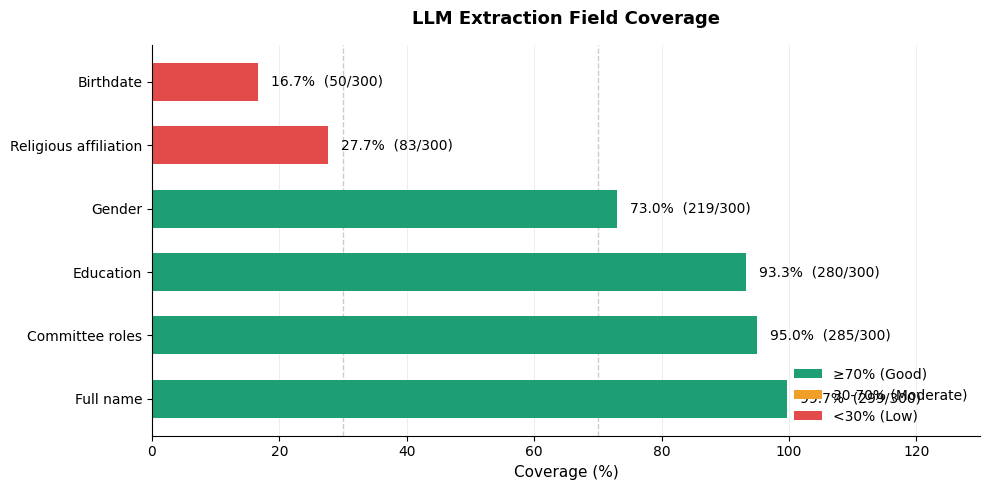

In [10]:
# ── Field Coverage Visualization ───────────────────────────────────────
# Generate a horizontal bar chart showing coverage per field from df_pred

import matplotlib.pyplot as plt
import numpy as np

# Setup
fields = ["full_name", "birthdate", "gender", "education", "committee_roles", "religious_affiliation"]
labels = ["Full name", "Birthdate", "Gender", "Education", "Committee roles", "Religious affiliation"]

# Calculate coverage per field
total = len(df_pred)
coverage_data = []
for col in fields:
    count = df_pred[col].notna().sum()
    pct = (count / total) * 100
    coverage_data.append({
        "label": labels[fields.index(col)],
        "count": count,
        "pct": pct,
        "total": total
    })

# Sort by percentage descending
coverage_data.sort(key=lambda x: x["pct"], reverse=True)

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Prepare data for plotting
y_pos = np.arange(len(coverage_data))
percentages = [item["pct"] for item in coverage_data]
labels_sorted = [item["label"] for item in coverage_data]
counts = [item["count"] for item in coverage_data]

# Define color function based on thresholds
def get_color(pct):
    if pct >= 70:
        return "#1D9E75"
    elif pct >= 30:
        return "#EF9F27"
    else:
        return "#E24B4A"

colors = [get_color(pct) for pct in percentages]

# Plot horizontal bars
bars = ax.barh(y_pos, percentages, color=colors, height=0.6)

# Add dashed vertical reference lines
ax.axvline(x=30, linestyle="--", color="#cccccc", linewidth=1, zorder=0)
ax.axvline(x=70, linestyle="--", color="#cccccc", linewidth=1, zorder=0)

# Annotate each bar with percentage and count
for i, (bar, item) in enumerate(zip(bars, coverage_data)):
    annotation_text = f"{item['pct']:.1f}%  ({item['count']}/{item['total']})"
    ax.text(
        item["pct"] + 2,
        bar.get_y() + bar.get_height() / 2,
        annotation_text,
        va="center",
        fontsize=10,
        fontweight="normal"
    )

# Set y-axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(labels_sorted)

# Set x-axis limits and labels
ax.set_xlim(0, 130)
ax.set_xlabel("Coverage (%)", fontsize=11)

# Add title
ax.set_title("LLM Extraction Field Coverage", fontsize=13, fontweight="bold", pad=15)

# Style: remove top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add light gridlines on x-axis
ax.grid(axis="x", alpha=0.3, linestyle="-", linewidth=0.5)
ax.set_axisbelow(True)

# Create legend for color tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", label="≥70% (Good)"),
    Patch(facecolor="#EF9F27", label="30-70% (Moderate)"),
    Patch(facecolor="#E24B4A", label="<30% (Low)")
]
ax.legend(handles=legend_elements, loc="lower right", frameon=False, fontsize=10)

# Adjust layout and save
plt.tight_layout()
output_file = OUTPUT_DIR.parent / "outputs" / "field_coverage.png"
output_file.parent.mkdir(exist_ok=True)
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"\n✓ Field coverage chart saved to: {output_file}")
plt.show()

## Baseline Comparison Methods

Implements traditional information extraction methods for comparison with LLM results (Liu et al. Section 5, Tables 4–5) - Uses modules.pipeline_runner.run_baselines() which orchestrates:

- **Regex baseline** — Rule-based patterns for name, email, phone
- **spaCy NER baseline** — Pre-trained neural entity recognition for PERSON, ORG, GEO

**Purpose:** Quantify LLM superiority on canonical PII extraction tasks. 
This section tests both methods on the same HTML data then compares coverage vs. LLM accuracy.

Returns coverage statistics and saves results to baselines.csv

In [11]:
from modules import run_baselines, REGEX_PATTERNS

# Configuration: set to True to recompute even if baselines.csv exists
BASELINE_OVERRIDE = True

baseline_csv_path = OUTPUT_DIR / "baselines.csv"

if baseline_csv_path.exists() and not BASELINE_OVERRIDE:
    print(f"✓ Baselines already computed (found: {baseline_csv_path.name})")
    print(f"  Set BASELINE_OVERRIDE = True to recompute")
else:
    print(f"Running baseline extraction...")
    baseline_metrics = run_baselines(
        html_files=html_files,
        nlp=nlp,
        regex_patterns=REGEX_PATTERNS,
        output_dir=OUTPUT_DIR
    )
    
    print(f"✓ Baseline extraction complete")
    print(f"  Results saved to: {baseline_csv_path}")

Running baseline extraction...


Running baselines:   0%|          | 0/100 [00:00<?, ?it/s]

/Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/.venv_py311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializin


✓ Baseline extraction complete: 100 senators
  Results saved to: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/senate_results/baselines.csv
✓ Baseline extraction complete
  Results saved to: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/senate_results/baselines.csv


In [12]:
from modules import load_baseline_results, print_baseline_summary

# Load baseline results
df_baselines = load_baseline_results(OUTPUT_DIR / "baselines.csv")

print(f"✓ Loaded baseline results: {len(df_baselines)} senators")
print(f"\nBaseline columns: {len(df_baselines.columns)}")
print(df_baselines.columns.tolist())

✓ Loaded baseline results: 100 senators

Baseline columns: 18
['senator_id', 'regex_name', 'regex_email_found', 'regex_phone_found', 'keyword_name', 'keyword_email', 'keyword_phone', 'keyword_education', 'spacy_name', 'spacy_state', 'spacy_affiliation', 'spacy_occupation', 'spacy_education', 'spacy_education_entries', 'spacy_committee_roles', 'spacy_committee_count', 'bert_persons_found', 'bert_orgs_found']


In [13]:
df_baselines.head()

,senator_id,regex_name,regex_email_found,regex_phone_found,keyword_name,keyword_email,keyword_phone,keyword_education,spacy_name,spacy_state,spacy_affiliation,spacy_occupation,spacy_education,spacy_education_entries,spacy_committee_roles,spacy_committee_count,bert_persons_found,bert_orgs_found
0,Adam_Schiff_CA,Schiff Skip,0,0,NaN,NaN,NaN,NaN,Schiff Skip,Massachusetts,Home Search Mobile Nav Open Open Search,NaN,NaN,0,"['member of the Senate Judiciary Committee', '...",11,5,10
1,Alan_Armstrong_OK,Armstrong Skip,0,0,NaN,Share Your Opinion,NaN,NaN,Armstrong Skip,NaN,dapibus,NaN,NaN,0,NaN,0,2,1
2,Alex_Padilla_CA,Alex Padilla,0,0,NaN,Español,NaN,NaN,Alex Padilla Skip,California,California Search Search,NaN,"[{'degree': 'Bachelor', 'institution': 'the Ma...",1,['Chair of Chair of the State Senate Committee...,3,2,5
3,Amy_Klobuchar_MN,Amy Klobuchar,0,0,NaN,Casework Contact,NaN,Public Safety and Criminal Justice Reform,Amy,Minnesota,the U.S. Senate,NaN,NaN,0,"['member of the Senate Agriculture Committee',...",9,5,4
4,Andy_Kim_NJ,Andy Kim,0,0,NaN,Newsletter,NaN,"On the Committee on Health, Education, Labor a...",Andy Kim,New Jersey,the U.S. Senate,NaN,NaN,0,['Member of My Pastimes Committee Work Committ...,11,2,7


In [14]:
from modules import print_baseline_summary

# Print formatted summary
print_baseline_summary(df_baselines, total_senators=len(html_files))


 BASELINE EXTRACTION COVERAGE (GROUND-TRUTH-SCORABLE FIELDS ONLY)

Total senators: 100
Note: Email & phone excluded (no ground truth available for evaluation)

REGEX BASELINE (Scorable fields):
  Names extracted:               99/100 ( 99.0%)

KEYWORD SEARCH BASELINE (Scorable fields):
  Names extracted:                1/100 (  1.0%)
  Education found:               24/100 ( 24.0%)

spaCy NER BASELINE (Scorable fields):
  Names extracted:              100/100 (100.0%)
  States found:                  97/100 ( 97.0%)
  Affiliations:                  99/100 ( 99.0%)
  Avg education entries/senator:   0.79

BERT NER BASELINE:
  ⚠ Entity counts only (no GT labels for persons/orgs)
  Avg persons/senator:   4.18
  Avg orgs/senator:      8.15

Legend: Only fields with ground truth are scored for accuracy in baseline_accuracy.csv


In [15]:
# ──────────────────────────────────────────────────────────────────
# COMPUTE BASELINE ACCURACY (NEW)
# ──────────────────────────────────────────────────────────────────

from modules.evaluation.suite import get_baseline_accuracy

# Load ground truth
ground_truth_path = Path("../external_data/ground_truth/senate_ground_truth_updated_manual.csv")
df_gt = pd.read_csv(ground_truth_path)

print(f"\n✓ Loaded ground truth: {len(df_gt)} senators")
print(f"  Ground truth columns: {df_gt.columns.tolist()[:8]}...")

# Compute accuracy for all baselines against ground truth
df_baseline_accuracy = get_baseline_accuracy(
    baseline_df=df_baselines,
    ground_truth_df=df_gt,
    output_dir=OUTPUT_DIR,
    verbose=True
)

# Check if results were generated
if df_baseline_accuracy is None or len(df_baseline_accuracy) == 0:
    print("⚠ WARNING: get_baseline_accuracy() returned no data.")
    print("  This likely means:")
    print("  1. The merging of baselines + GT failed (no common senator_id values)")
    print("  2. The function has a bug — check suite.py for explicit return statement")
    print("\n  Debugging info:")
    print(f"  - Baselines senators: {df_baselines['senator_id'].nunique()}")
    print(f"  - GT senators: {df_gt['senator_id'].nunique()}")
    print(f"  - Common: {df_baselines['senator_id'].isin(df_gt['senator_id']).sum()}")
else:
    # Display sample results
    print("\nSAMPLE BASELINE ACCURACY RESULTS:")
    print("─" * 80)
    print(df_baseline_accuracy.head(20).to_string())
    print(f"\n✓ Generated {len(df_baseline_accuracy)} accuracy rows")


✓ Loaded ground truth: 100 senators
  Ground truth columns: ['senator_id', 'name', 'full_name', 'birthdate', 'gender', 'race_ethnicity', 'committee_roles', 'religion']...

 COMPUTING BASELINE ACCURACY METRICS (GT-SCORABLE FIELDS ONLY)

✓ Merged 100 senators with ground truth

ACCURACY SUMMARY BY BASELINE METHOD & FIELD:
────────────────────────────────────────────────────────────────────────────────
                              mean       std  count  min     max
baseline_method field                                           
Keyword         education  0.00129  0.007764     99  0.0  0.0625
                name       0.00000  0.000000    100  0.0  0.0000
Regex           name       0.73000  0.446196    100  0.0  1.0000
spaCy           education  0.29798  0.356565     99  0.0  1.0000
                name       0.24000  0.429235    100  0.0  1.0000


OVERALL BY BASELINE (all scorable fields):
────────────────────────────────────────
                     mean  count
baseline_method       

In [16]:
# Ensure sys.path includes parent directory for module imports
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

# ──────────────────────────────────────────────────────────────────
# BUILD BASELINE SUMMARY TABLE (Liu et al. Style)
# ──────────────────────────────────────────────────────────────────

from modules.evaluation.suite import build_baseline_summary_table

# Generate summary table matching Liu et al. Tables 4-5 format
# Shows accuracy metrics by baseline method and field
# Rows = baselines (Regex, Keyword, spaCy, BERT)
# Columns = PIE fields (name, education, affiliation, occupation, committee_roles)
# Values = mean accuracy per field/baseline combination

if df_baseline_accuracy is not None and len(df_baseline_accuracy) > 0:
    print("\n" + "=" * 100)
    print("BASELINE ACCURACY SUMMARY TABLE")
    print("=" * 100)
    
    df_summary = build_baseline_summary_table(
        df_accuracy=df_baseline_accuracy,
        include_bert=False,  # Set to True to include BERT scores in "X% / Y.YY" format
        verbose=True
    )
else:
    print("⚠ Cannot generate summary table: df_baseline_accuracy is empty or None")


BASELINE ACCURACY SUMMARY TABLE

 Table X: Effectiveness of traditional PIE methods (senator dataset)

             name education affiliation occupation committee_roles
Regex         73%         —           —          —               —
Keyword        0%        0%           —          —               —
spaCy         24%       30%           —          —               —
Metric   Accuracy   Rouge-1     Rouge-1          —         Rouge-1

Sample counts (n) per baseline and field:
----------------------------------------------------------------------------------------------------

                 name education affiliation occupation committee_roles
baseline_method                                                       
Regex             100         —           —          —               —
Keyword           100        99           —          —               —
spaCy             100        99           —          —               —

Accuracy for name; Rouge-1 score for text fields. '—' indica

✓ Baseline coverage chart saved to: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/outputs/baseline_coverage.png


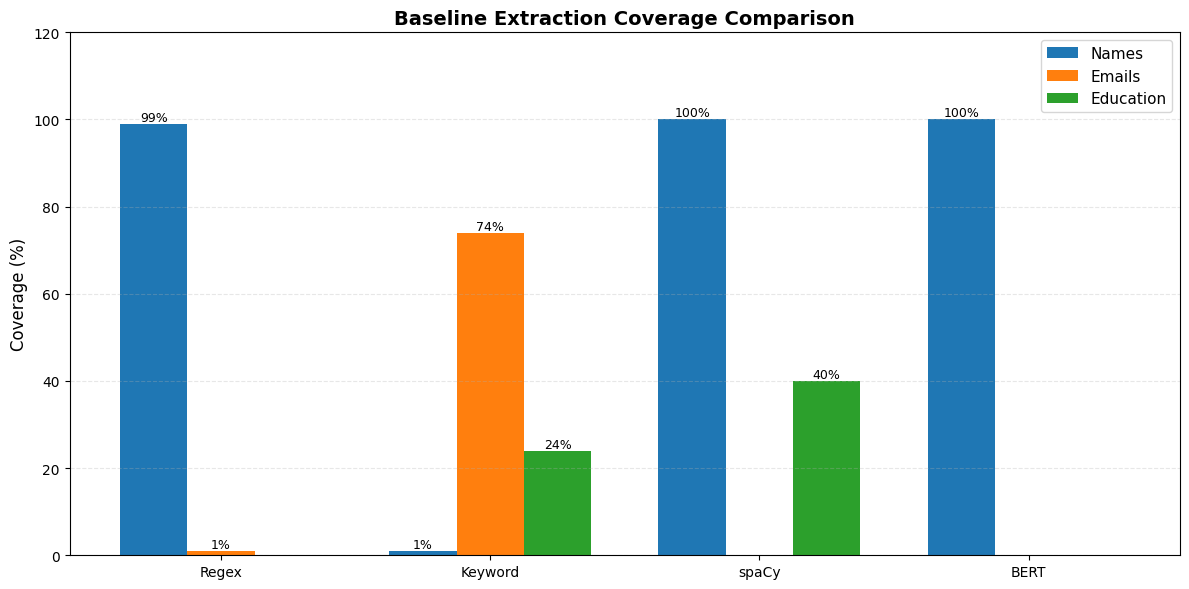

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare coverage data
baselines = ["Regex", "Keyword", "spaCy", "BERT"]
name_coverage = [
    (df_baselines["regex_name"].notna()).sum(),
    (df_baselines["keyword_name"].notna()).sum(),
    (df_baselines["spacy_name"].notna()).sum(),
    len(df_baselines),  # BERT always returns persons (approximate)
]

email_coverage = [
    (df_baselines["regex_email_found"] > 0).sum(),
    (df_baselines["keyword_email"].notna()).sum(),
    0,  # spaCy doesn't extract emails directly
    0,  # BERT doesn't extract emails directly
]

education_coverage = [
    0,  # Regex doesn't extract education
    (df_baselines["keyword_education"].notna()).sum(),
    (df_baselines["spacy_education_entries"] > 0).sum(),
    0,  # BERT is org-based, not education
]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(baselines))
width = 0.25

total = len(df_baselines)
bars1 = ax.bar(x - width, [c/total*100 for c in name_coverage], width, label="Names", color="#1f77b4")
bars2 = ax.bar(x, [c/total*100 for c in email_coverage], width, label="Emails", color="#ff7f0e")
bars3 = ax.bar(x + width, [c/total*100 for c in education_coverage], width, label="Education", color="#2ca02c")

# Labels and formatting
ax.set_ylabel("Coverage (%)", fontsize=12)
ax.set_title("Baseline Extraction Coverage Comparison", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(baselines)
ax.legend(loc="upper right", fontsize=11)
ax.set_ylim(0, 120)

# Add percentage labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.0f}%',
                   ha='center', va='bottom', fontsize=9)

ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

output_file = OUTPUT_DIR.parent / "outputs" / "baseline_coverage.png"
output_file.parent.mkdir(exist_ok=True)
plt.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"✓ Baseline coverage chart saved to: {output_file}")
plt.show()

In [18]:
# Quick comparison: How many fields does each baseline extract vs LLM?

print("\n" + "=" * 80)
print(" BASELINE vs LLM COMPARISON")
print("=" * 80)

# Calculate LLM coverage from task1_pii.csv
llm_name_coverage = (df_pred["full_name"].notna()).sum()
llm_education_coverage = (df_pred["education"].notna()).sum()

# Calculate baseline coverage
spacy_name_coverage = (df_baselines["spacy_name"].notna()).sum()
spacy_education_coverage = (df_baselines["spacy_education_entries"] > 0).sum()

total = len(df_baselines)

print(f"\nNAME EXTRACTION:")
print(f"  LLM (Groq):      {llm_name_coverage:3d}/{total} ({100*llm_name_coverage/total:5.1f}%)")
print(f"  spaCy NER:       {spacy_name_coverage:3d}/{total} ({100*spacy_name_coverage/total:5.1f}%)")
print(f"  Regex:           {(df_baselines['regex_name'].notna()).sum():3d}/{total} ({100*(df_baselines['regex_name'].notna()).sum()/total:5.1f}%)")

print(f"\nEDUCATION EXTRACTION:")
print(f"  LLM (Groq):      {llm_education_coverage:3d}/{total} ({100*llm_education_coverage/total:5.1f}%)")
print(f"  spaCy NER:       {spacy_education_coverage:3d}/{total} ({100*spacy_education_coverage/total:5.1f}%)")
print(f"  Keyword Search:  {(df_baselines['keyword_education'].notna()).sum():3d}/{total} ({100*(df_baselines['keyword_education'].notna()).sum()/total:5.1f}%)")

print("\n" + "=" * 80)


 BASELINE vs LLM COMPARISON

NAME EXTRACTION:
  LLM (Groq):      299/100 (299.0%)
  spaCy NER:       100/100 (100.0%)
  Regex:            99/100 ( 99.0%)

EDUCATION EXTRACTION:
  LLM (Groq):      280/100 (280.0%)
  spaCy NER:        40/100 ( 40.0%)
  Keyword Search:   24/100 ( 24.0%)



## Ground Truth Extraction & Building

(Re)generate ground truth CSV from Wikipedia, Ballotpedia, and Pew religion data.

This step is optional if ground_truth CSV already exists and is up-to-date. 
Use this to refresh ground truth with new scraper versions or updated senator data.

**Key Features:**
- Resume-safe: Skips senators already processed; continue from checkpoint
- Rate-limited: Respectful delays between requests to external sites
- Merged sources: Wikipedia (bio data) + Ballotpedia (committees) + Pew (religion)
- Logging: Warnings logged for any scrape failures; check if needed

**Runtime:** ~1-2 minutes for full senate (104 senators × 0.5s delay) or faster with resume

In [19]:
# Import ground truth builder
import sys
sys.path.insert(0, '../scripts')
from build_ground_truth import build_ground_truth

# Define paths
GT_HTML_DIR = Path("../external_data/senate_html")
GT_PEW_PATH = Path("../external_data/ground_truth/pew_religion.csv")
GT_OUTPUT_PATH = Path("../external_data/ground_truth/senate_ground_truth.csv")
GT_COMMITTEE_YAML_PATH = Path("../external_data/ground_truth/committee-membership-current.yaml")
GT_COMMITTEES_YAML_PATH = Path("../external_data/ground_truth/committees-current.yaml")

# Build/update ground truth
print("=" * 60)
print("GROUND TRUTH EXTRACTION")
print("=" * 60)

df_gt = build_ground_truth(
    html_dir=GT_HTML_DIR,
    pew_path=GT_PEW_PATH,
    output_path=GT_OUTPUT_PATH,
    committee_yaml_path=GT_COMMITTEE_YAML_PATH,
    committees_yaml_path=GT_COMMITTEES_YAML_PATH,
    resume=True  # Skip already-processed senators; continue from checkpoint
)

GROUND TRUTH EXTRACTION
📋 Resuming from checkpoint: ../external_data/ground_truth/senate_ground_truth.csv
   Already completed: 100 senators
📂 Reading senator HTML files from ../external_data/senate_html...
   Found: 100 senators
   To process: 0 senators

✓ All senators already processed. Skipping rebuild.


### Ground Truth Validation and Loading

Validate and load ground truth CSV generated by wiki/ballotpedia scraping phase.
Ground truth includes: name, birthdate, gender, religion (Pew-sourced), committee_roles.
This is critical input for the evaluation phase that compares LLM predictions vs ground truth.

In [20]:


OUTPUT_PATH = Path("../external_data/ground_truth/senate_ground_truth_updated_manual.csv")

if not OUTPUT_PATH.exists():
    print(f"⚠ Ground truth file not found: {OUTPUT_PATH} - evaluation will not work without it.")
    df_gt = None
else:
    df_gt = pd.read_csv(OUTPUT_PATH)
    print("Ground Truth Summary:")
    print(f"  Total senators: {len(df_gt)}")
    print(f"  Fields available: {len(df_gt.columns)}")
    print(f"  Empty fields per senator (avg): {df_gt.isna().sum().mean():.1f}")
    
    # Show field coverage
    print("\nField Coverage (Ground Truth):")
    for col in ["name", "birthdate", "gender", "religion", "committee_roles", "education"]:
        if col in df_gt.columns:
            covered = df_gt[col].notna().sum()
            pct = 100 * covered / len(df_gt)
            print(f"  {col:20s}: {covered:3d}/{len(df_gt)} ({pct:5.1f}%)")
    
    print(f"\n✓ Ground truth ready for evaluation")

Ground Truth Summary:
  Total senators: 100
  Fields available: 10
  Empty fields per senator (avg): 0.5

Field Coverage (Ground Truth):
  name                : 100/100 (100.0%)
  birthdate           : 100/100 (100.0%)
  gender              : 100/100 (100.0%)
  religion            :  97/100 ( 97.0%)
  committee_roles     :  99/100 ( 99.0%)
  education           :  99/100 ( 99.0%)

✓ Ground truth ready for evaluation


### Structured Evaluation and Scoring
Compare LLM predictions vs ground truth using modules from evaluation_suite.

Key features (from modules.evaluation_suite and modules.evaluator):
- Automatic result caching (evaluate_all_styles checks cache before recomputing)
- Stratified metrics: accuracy, ROUGE-1, BERT score, hierarchical religion match
- Component-level breakdown for education (degree/institution/year matching)
- Supports fuzzy name matching fallback for senator_id mismatches

Runtime: 30-90 seconds (much faster on second run due to caching)

In [21]:
from modules import (
    load_and_merge_results,
    evaluate_all_styles,
    print_evaluation_summary,
)

In [22]:
# Load and merge all predictions with ground truth
print("Loading predictions and ground truth...")
merged_data = load_and_merge_results(
    pred_path=OUTPUT_DIR / "task1_pii.csv",
    gt_path=Path("../external_data/ground_truth/senate_ground_truth_updated_manual.csv"),
    merge_method="exact"
)

Loading predictions and ground truth...
✓ Loaded 300 predictions
✓ Loaded 100 ground truth records
✓ Prompt styles: <StringArray>
['direct', 'pseudocode', 'icl']
Length: 3, dtype: str



In [23]:
# Compute evaluation metrics with caching (Second run on same data will load cached results instead of recomputing)
print("\nComputing evaluation metrics...")
eval_results = evaluate_all_styles(
    merged_by_style=merged_data['merged_by_style'],
    output_dir=OUTPUT_DIR,
    overwrite=True  # Set to True to recompute even if cache exists
)


Computing evaluation metrics...
Evaluating [DIRECT] (100 records)


/Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/.venv_py311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/.venv_py311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed 

Evaluating [PSEUDOCODE] (100 records)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/.venv_py311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe

Evaluating [ICL] (100 records)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/.venv_py311/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and infe


✓ Cached evaluation results to /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/senate_results/evaluation_results_cache.json


In [24]:
# Print formatted summary
print_evaluation_summary(eval_results)


 EVALUATION RESULTS BY PROMPT STYLE

PROMPT STYLE: DIRECT               (n=100)

Accuracy   — full_name (exact)        :  85.00%  (n_gt=100, n_pred=100)
Accuracy   — gender (exact)           : 100.00%  (n_gt=100, n_pred=100)
Accuracy   — birthdate_exact          :  75.00%  (n_gt=100, n_pred=16)
Accuracy   — birthdate_year           :  93.75%  (n_gt=100, n_pred=16)
Accuracy   — birthdate_month          :  75.00%  (n_gt=100, n_pred=16)
Accuracy   — religion                 :  58.29%  (n_gt=97, n_pred=42)
Rouge-1    — education rouge1         : 0.259  (n_gt=99, n_pred=100)
Rouge-1    — committee roles rouge1   : 0.309  (n_gt=99, n_pred=100)
BERT score — education                : F1=0.604  (n_gt=99, n_pred=100)
BERT score — committee roles          : F1=0.781  (n_gt=99, n_pred=100)

── Education Components (Detailed) ──
  combined component bert:  73.02%
  combined score      :  47.24%
  degree bert         :  60.79%
  degree exact        :  24.56%
  institution bert    :  85.25%
  insti

### Export Ground Truth vs Predictions Comparison

Build a side-by-side comparison CSV using the already-computed evaluation results.
This exports one row per senator with ground truth, predictions, and match scores for all 6 attributes.


In [25]:
# Build comparison file with per-row match scores for ALL prompt styles
# Saves to Excel with one sheet per prompt style
#
# REFACTORED: Uses modules.evaluation_suite.get_per_row_scores() to ensure
# per-row scoring uses exact same NaN/0 semantics as aggregate evaluation metrics.
# Eliminates code duplication and guarantees consistency.

print("\n" + "=" * 80)
print(" BUILDING COMPARISON FILE WITH PER-ROW MATCH SCORES (ALL STYLES)")
print("=" * 80)

import numpy as np
from modules import get_per_row_scores
from modules.config.config_unified import RELIGION_HIERARCHY

# Build comparison for each prompt style using unified scoring logic
all_comparison_dfs = {}

for style in ["direct", "pseudocode", "icl"]:
    if style in merged_data['merged_by_style']:
        merged_style = merged_data['merged_by_style'][style]
        print(f"\nProcessing '{style}' prompt style: {len(merged_style)} senators")
        
        # Use the shared scoring function from evaluation_suite
        # This ensures per-row scores match aggregate metrics exactly
        comparison_df = get_per_row_scores(
            merged_df=merged_style,
            style=style,
            religion_hierarchy=RELIGION_HIERARCHY
        )
        all_comparison_dfs[style] = comparison_df
        
        print(f"  ✓ Comparison DataFrame created: {len(comparison_df)} rows × {len(comparison_df.columns)} columns")
        if "overall_match_score" in comparison_df.columns:
            print(f"  ✓ Avg overall match score: {comparison_df['overall_match_score'].mean():.3f}")
        
        # Check data fill rate
        pred_cols_list = [c for c in comparison_df.columns if c.endswith("_predicted")]
        if pred_cols_list:
            filled_preds = comparison_df[pred_cols_list].notna().sum().sum()
            total_preds = len(comparison_df) * len(pred_cols_list)
            print(f"  ✓ Predictions filled: {filled_preds}/{total_preds} ({100*filled_preds/total_preds:.1f}%)")

# Write all DataFrames to Excel with one sheet per style
comparison_output = OUTPUT_DIR / "ground_truth_predictions_comparison.xlsx"

with pd.ExcelWriter(comparison_output, engine='openpyxl') as writer:
    for style in ["direct", "pseudocode", "icl"]:
        if style in all_comparison_dfs:
            all_comparison_dfs[style].to_excel(writer, sheet_name=style, index=False)

print(f"\n✓ Excel file saved to: {comparison_output}")
print(f"  Sheets: {', '.join(all_comparison_dfs.keys())}")

# Print summary stats for all styles
print(f"\n" + "=" * 80)
print(" SUMMARY STATISTICS BY PROMPT STYLE")
print("=" * 80)

for style in ["direct", "pseudocode", "icl"]:
    if style in all_comparison_dfs:
        comparison_df = all_comparison_dfs[style]
        score_cols = [col for col in comparison_df.columns if col.endswith("_match_score")]
        
        print(f"\n{style.upper()} PROMPT STYLE:")
        print(f"  Total senators: {len(comparison_df)}")
        if score_cols and "overall_match_score" in comparison_df.columns:
            print(f"  Avg overall match score: {comparison_df['overall_match_score'].mean():.3f}")
        print(f"\n  Per-attribute match scores (avg):")
        for score_col in score_cols:
            attr_name = score_col.replace("_match_score", "")
            valid_scores = comparison_df[score_col].dropna()
            if len(valid_scores) > 0:
                print(f"    {attr_name:20s}: mean={valid_scores.mean():.3f}, n={len(valid_scores)}/{len(comparison_df)}")
            else:
                print(f"    {attr_name:20s}: NO DATA")

print(f"\n✅ Comparison file successfully created!")


 BUILDING COMPARISON FILE WITH PER-ROW MATCH SCORES (ALL STYLES)

Processing 'direct' prompt style: 100 senators
  ✓ Comparison DataFrame created: 100 rows × 26 columns
  ✓ Avg overall match score: 0.512
  ✓ Predictions filled: 458/600 (76.3%)

Processing 'pseudocode' prompt style: 100 senators
  ✓ Comparison DataFrame created: 100 rows × 26 columns
  ✓ Avg overall match score: 0.471
  ✓ Predictions filled: 401/600 (66.8%)

Processing 'icl' prompt style: 100 senators
  ✓ Comparison DataFrame created: 100 rows × 26 columns
  ✓ Avg overall match score: 0.471
  ✓ Predictions filled: 349/600 (58.2%)

✓ Excel file saved to: /Users/chloe/Library/Mobile Documents/com~apple~CloudDocs/UNCC MS DSBA/Data Privacy/Final Project/LLM-Based-Personal-Profile-Extraction-V2/outputs/senate_results/ground_truth_predictions_comparison.xlsx
  Sheets: direct, pseudocode, icl

 SUMMARY STATISTICS BY PROMPT STYLE

DIRECT PROMPT STYLE:
  Total senators: 100
  Avg overall match score: 0.512

  Per-attribute matc

## Prompt Engineering Ablation Study

Rigorous comparison of all three prompt styles on a **fixed held-out subset of 25 senators**.
Each senator is extracted independently using direct, pseudocode, and ICL prompts.

**Purpose:** Quantify which fields benefit most from structured prompts (e.g., pseudocode) vs. demonstrations (e.g., ICL).
This replicates Liu et al.'s ablation methodology (Section 4.2, Table 13).

**Reproducibility:**
- Fixed random seed (42) ensures same 25 senators across runs
- Separate results file (`ablation_results.json`) keeps ablation independent from main pipeline
- Resume-safe — skips already-completed combinations
- 3-second rate limit between API calls to respect quota

**Expected outcome:** ICL shows largest gains on education, committee roles, and religious affiliation (Liu et al. reports ~15-25% improvement)

## Prompt Engineering Ablation Study

Rigorous comparison of all three prompt styles on a **fixed held-out subset of 25 senators**.
Each senator is extracted independently using direct, pseudocode, and ICL prompts.

**Purpose:** Quantify which fields benefit most from structured prompts (e.g., pseudocode) vs. demonstrations (e.g., ICL).
This replicates Liu et al.'s ablation methodology (Section 4.2, Table 13).

**Reproducibility:**
- Fixed random seed (42) ensures same 25 senators across runs
- Separate results file (`ablation_results.json`) keeps ablation independent from main pipeline
- Resume-safe — skips already-completed combinations
- 3-second rate limit between API calls to respect quota

**Expected outcome:** ICL shows largest gains on education, committee roles, and religious affiliation (Liu et al. reports ~15-25% improvement)

In [26]:
# ABLATION STUDY EXECUTION
# Test all three prompt styles (direct, pseudocode, ICL) on the fixed ablation subset.
# Uses modules.api.call_groq() and modules.html_processing.extract_readable_text().
#
# Resume-safe implementation: 
#   - Loads existing ablation_results.json if present
#   - Tracks which (senator_id, style) combinations are already complete
#   - Continues from where it left off if interrupted
#
# Rate limit protection: 3-second delay between API calls

from modules import (
    TASK1_DIRECT, TASK1_PSEUDOCODE, TASK1_ICL,
    extract_readable_text, call_groq
)

# Define all prompt styles for ablation (same templates as main pipeline)
ABLATION_STYLES = {
    "direct": TASK1_DIRECT,
    "pseudocode": TASK1_PSEUDOCODE,
    "icl": TASK1_ICL
}

# Load or initialize ablation results from disk
ablation_path = OUTPUT_DIR / "ablation_results.json"

if ablation_path.exists():
    with open(ablation_path) as f:
        ablation_results = json.load(f)
    # Track which (senator_id, style) combos are already completed
    completed = set()
    for sid, styles_dict in ablation_results.items():
        for style in styles_dict.keys():
            completed.add((sid, style))
    print(f"✓ Resuming — {len(completed)} senator-style combinations already processed")
else:
    ablation_results = {}
    completed = set()

# Compute remaining tasks: each senator needs extraction with all 3 styles
ablation_tasks = [(sid, style) for sid in ablation_senators for style in ABLATION_STYLES.keys()]
remaining_tasks = [t for t in ablation_tasks if t not in completed]

print(f"Remaining ablation tasks: {len(remaining_tasks)}/{len(ablation_tasks)}")
print()

# Main ablation loop: extract each senator with each prompt style
for senator_id, style_name in tqdm(remaining_tasks, desc="Ablation loop"):
    # Load HTML and extract clean text (same preprocessing as main pipeline)
    html_file = [f for f in html_files if f.stem == senator_id]
    if not html_file:
        continue
    
    # Read and clean HTML
    html = html_file[0].read_text(encoding="utf-8", errors="ignore")
    text = extract_readable_text(html)
    
    # Extract with current style using Groq API (via modules.api.call_groq)
    prompt = ABLATION_STYLES[style_name]
    result = call_groq(prompt, text)
    
    # Store result in nested dict: {senator_id: {style_name: result, ...}, ...}
    if senator_id not in ablation_results:
        ablation_results[senator_id] = {}
    
    ablation_results[senator_id][style_name] = result
    
    # Save incrementally (critical for resume safety and data preservation)
    with open(ablation_path, "w") as f:
        json.dump(ablation_results, f, indent=2)
    
    # Rate limit protection — 3 seconds between API calls to avoid quota errors
    time.sleep(3)

print(f"\n✓ Ablation complete. Results saved to: ablation_results.json")

Remaining ablation tasks: 75/75



Ablation loop:   0%|          | 0/75 [00:00<?, ?it/s]

ERROR:senate_pipeline.api:call_groq: config parameter is required (SessionConfig object)


ValueError: config parameter is required (SessionConfig object)

In [ ]:
# ABLATION COVERAGE COMPARISON
# Analyze field coverage per prompt style for the fixed ablation subset.
# This shows which fields benefit from each prompt engineering approach.
#
# Display table: rows = fields, columns = prompt styles (direct, pseudocode, ICL)
# Then calculate average coverage per style for high-level comparison.

print("\n" + "=" * 80)
print(" PROMPT ABLATION — FIELD COVERAGE COMPARISON")
print("=" * 80)
print(f"\nAblation subset size: {len(ablation_senators)} senators")
print(f"Ablation styles: {', '.join(ABLATION_STYLES.keys())}")
print()

# Calculate coverage for each field by prompt style
coverage_by_style = {}
for style in ABLATION_STYLES.keys():
    style_data = df_ablation[df_ablation["prompt_style"] == style].copy()

    error_mask = style_data.get("extraction_error", pd.Series(dtype=str)).notna()
    valid_data = style_data[~error_mask]
    n_errors = int(error_mask.sum())
    n_valid = len(valid_data)

    if n_valid == 0:
        print(f"  ⚠ {style}: all {n_errors} results are errors — delete ablation_results.json and rerun")
        continue

    coverage_by_style[style] = {}
    for field in T1_FIELDS_ABLATION:
        filled = int(valid_data[field].notna().sum())
        pct = (filled / n_valid * 100)
        coverage_by_style[style][field] = {"filled": filled, "total": n_valid, "pct": pct}

if not coverage_by_style:
    print("⚠ No valid results to display.")
else:
    # Print coverage table
    print(f"{'Field':<35} | {'DIRECT':^15} | {'PSEUDOCODE':^15} | {'ICL':^15}")
    print("-" * 80)
    for field in T1_FIELDS_ABLATION:
        row_str = f"{field:<35} | "
        for style in ["direct", "pseudocode", "icl"]:
            if style in coverage_by_style:
                c = coverage_by_style[style][field]
                row_str += f"{c['filled']}/{c['total']} ({c['pct']:5.1f}%) | "
            else:
                row_str += f"{'N/A':^15} | "
        print(row_str)
    print("=" * 80)

    # Show average coverage per style
    print("\n OVERALL COVERAGE BY PROMPT STYLE:")
    for style in ["direct", "pseudocode", "icl"]:
        if style in coverage_by_style:
            avg_cov = sum(coverage_by_style[style][f]["pct"] for f in T1_FIELDS_ABLATION) / len(T1_FIELDS_ABLATION)
            print(f"  {style:<15}: {avg_cov:6.1f}% (avg across all fields)")
        else:
            print(f"  {style:<15}: N/A (all errors)")

    print("\n KEY OBSERVATIONS:")
    print("  • Compare direct vs pseudocode: Liu et al. find pseudocode slightly better for structured fields")
    print("  • Compare direct/pseudocode vs ICL: Liu et al. find ICL best for occupation-type fields")
    print("    (committee_roles, education, religious_affiliation)")
    print("=" * 80 + "\n")

## Appendix: Religion Taxonomy & Hierarchical Matching

To give partial credit for related religions (e.g., Methodist → Christian),
we use a hierarchical taxonomy. Exact matches score 1.0, parent-child matches
(e.g., Methodist vs Christian) score 0.7, and unrelated religions score 0.0.

This better reflects partial correctness: extracting "Christian Methodist" when
GT is "Methodist" is partially correct even if not exact.

**Scoring Details:**
- **1.0** — Exact match (Methodist = Methodist)
- **0.7** — Same religious category but different names (Methodist vs Christian, Baptist vs Protestant)
- **0.0** — Different religions (Methodist vs Catholic, Christian vs Muslim)
- **NaN** — Either value missing (not scored)

This approach is implemented in `modules.evaluator.religion_match_score()` and uses the `RELIGION_HIERARCHY` dictionary from `modules.config_unified`.